In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [3]:
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

In [9]:
data = pd.read_csv(r"C:\Suren\Academmics\6th sem\AI & EDGE COMPUTING\Lab\Data Sets\Week 9\global air pollution dataset.csv")
data

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good
...,...,...,...,...,...,...,...,...,...,...,...,...
23458,India,Gursahaiganj,184,Unhealthy,3,Good,154,Unhealthy,2,Good,184,Unhealthy
23459,France,Sceaux,50,Good,1,Good,20,Good,5,Good,50,Good
23460,India,Mormugao,50,Good,1,Good,22,Good,1,Good,50,Good
23461,United States of America,Westerville,71,Moderate,1,Good,44,Good,2,Good,71,Moderate


data.info()

In [13]:
data.isna().sum()

Country               427
City                    1
AQI Value               0
AQI Category            0
CO AQI Value            0
CO AQI Category         0
Ozone AQI Value         0
Ozone AQI Category      0
NO2 AQI Value           0
NO2 AQI Category        0
PM2.5 AQI Value         0
PM2.5 AQI Category      0
dtype: int64

In [19]:
data=data.iloc[:,[3,5,7,9,2,4,6,8,10,11]]
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23463 entries, 0 to 23462
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   AQI Category        23463 non-null  object
 1   CO AQI Category     23463 non-null  object
 2   Ozone AQI Category  23463 non-null  object
 3   NO2 AQI Category    23463 non-null  object
 4   AQI Value           23463 non-null  int64 
 5   CO AQI Value        23463 non-null  int64 
 6   Ozone AQI Value     23463 non-null  int64 
 7   NO2 AQI Value       23463 non-null  int64 
 8   PM2.5 AQI Value     23463 non-null  int64 
 9   PM2.5 AQI Category  23463 non-null  object
dtypes: int64(5), object(5)
memory usage: 1.8+ MB


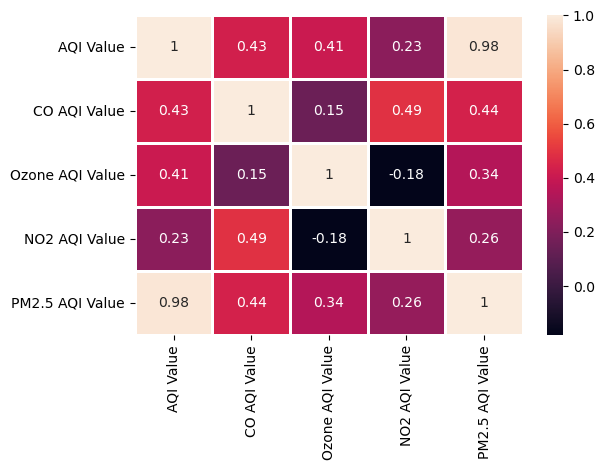

In [23]:
sns.heatmap(data.iloc[:, 4:-1].corr(), annot=True, linewidths=1)
plt.tight_layout()
plt.show()

In [31]:
def label(i):
    data[i] = LabelEncoder().fit_transform(data[i])
    return data[i]

for i in data.iloc[:, :4].columns:label(i)
data

,AQI Category,CO AQI Category,Ozone AQI Category,NO2 AQI Category,AQI Value,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value,PM2.5 AQI Category
0,2,0,0,0,51,1,36,0,51,Moderate
1,0,0,0,0,41,1,5,1,41,Good
2,2,0,0,0,66,1,39,2,66,Moderate
3,0,0,0,0,34,1,34,0,20,Good
4,0,0,0,0,22,0,22,0,6,Good
...,...,...,...,...,...,...,...,...,...,...
23458,3,0,2,0,184,3,154,2,184,Unhealthy
23459,0,0,0,0,50,1,20,5,50,Good
23460,0,0,0,0,50,1,22,1,50,Good
23461,2,0,0,0,71,1,44,2,71,Moderate


In [61]:
from sklearn.model_selection import train_test_split
col = list(data.columns)
predictor = col[:-1]  # Exclude target column
target = col[-1]  # Target column
train, test = train_test_split(data, test_size=0.2, random_state=0, stratify=data[target])

display(train)
display(test)


,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
21696,166,14543,51,2,1,0,29,0,5,0,51,2
19023,151,20841,30,0,1,0,30,0,0,0,7,0
22593,166,4941,101,4,2,0,10,0,14,0,101,4
18396,69,1650,152,3,3,0,87,1,1,0,152,3
3384,77,8649,33,0,1,0,33,0,3,0,20,0
...,...,...,...,...,...,...,...,...,...,...,...,...
21848,164,11779,30,0,0,0,30,0,3,0,16,0
13248,20,23301,50,0,1,0,31,0,0,0,50,0
13977,22,9276,25,0,0,0,7,0,0,0,25,0
12775,146,11735,25,0,1,0,25,0,1,0,18,0


,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
654,175,10150,33,0,1,0,17,0,8,0,33,0
8206,116,18764,162,3,1,0,39,0,0,0,162,3
13481,22,1841,48,0,1,0,10,0,2,0,48,0
7400,32,13666,45,0,1,0,10,0,5,0,45,0
14864,61,14746,95,2,3,0,14,0,10,0,95,2
...,...,...,...,...,...,...,...,...,...,...,...,...
23022,130,2436,31,0,1,0,31,0,0,0,27,0
1,22,16546,41,0,1,0,5,0,1,0,41,0
7503,69,8936,151,3,5,0,19,0,10,0,151,3
16883,100,20897,123,4,1,0,21,0,1,0,123,4


In [57]:
model = DecisionTreeClassifier(random_state=0)

model.fit(train[predictor], train[target])

print("For Test Data")
test_pred = model.predict(test[predictor])

from sklearn.metrics import confusion_matrix, accuracy_score

display(pd.crosstab(test[target], test_pred, rownames=["Actual"], colnames=["Prediction"]))
display(accuracy_score(test[target], test_pred))

print()
print("For Train Data")
train_pred = model.predict(train[predictor])

from sklearn.metrics import confusion_matrix, accuracy_score
display(pd.crosstab(train[target], train_pred, rownames=["Actual"], colnames=["Prediction"]))
print(accuracy_score(train[target], train_pred))


For Test Data


Prediction,0,1,2,3,4,5
Actual,,,,,,
0,2042,0,0,0,0,0
1,0,34,0,0,0,0
2,0,0,1815,0,0,0
3,0,0,0,426,0,0
4,0,0,0,0,325,0
5,0,0,0,0,0,51


1.0


For Train Data


Prediction,0,1,2,3,4,5
Actual,,,,,,
0,8166,0,0,0,0,0
1,0,138,0,0,0,0
2,0,0,7260,0,0,0
3,0,0,0,1703,0,0
4,0,0,0,0,1299,0
5,0,0,0,0,0,204


1.0


In [63]:
from sklearn.model_selection import RandomizedSearchCV

param = {
    "criterion": ["gini", "entropy", "log_loss"],
    "splitter": ["best", "random"],
    "max_depth": list(range(1, 50)),
    "min_samples_split": list(range(2, 50)),
    "min_samples_leaf": list(range(1, 50)),
    "max_features": ["auto", "sqrt", "log2"],
    "max_leaf_nodes": list(range(1, 50))
}

model = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=0),
    param_distributions=param,
    scoring="accuracy",
    n_jobs=-1,
    random_state=0,
    cv=5
).fit(train[predictor], train[target])

model

RandomizedSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=0),
                   n_jobs=-1,
                   param_distributions={'criterion': ['gini', 'entropy',
                                                      'log_loss'],
                                        'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9,
                                                      10, 11, 12, 13, 14, 15,
                                                      16, 17, 18, 19, 20, 21,
                                                      22, 23, 24, 25, 26, 27,
                                                      28, 29, 30, ...],
                                        'max_features': ['auto', 'sqrt',
                                                         'log2'],
                                        'max_leaf_nodes': [1, 2, 3, 4, 5, 6, 7,
                                                           8, 9, 10, 11, 12, 13,
                                                           14, 15, 16, 17, 18,
                                                           19, 20, 21, 22, 23,
                                                           24, 25, 26, 27, 28,
                                                           29, 30, ...],
                                        'min_samples_leaf': [1, 2, 3, 4, 5, 6,
                                                             7, 8, 9, 10, 11,
                                                             12, 13, 14, 15, 16,
                                                             17, 18, 19, 20, 21,
                                                             22, 23, 24, 25, 26,
                                                             27, 28, 29, 30, ...],
                                        'min_samples_split': [2, 3, 4, 5, 6, 7,
                                                              8, 9, 10, 11, 12,
                                                              13, 14, 15, 16,
                                                              17, 18, 19, 20,
                                                              21, 22, 23, 24,
                                                              25, 26, 27, 28,
                                                              29, 30, 31, ...],
                                        'splitter': ['best', 'random']},
                   random_state=0, scoring='accuracy')

In [65]:
print("For Test Data")
test_pred = model.predict(test[predictor])

from sklearn.metrics import confusion_matrix, accuracy_score

display(pd.crosstab(test[target], test_pred, rownames=["Actual"], colnames=["Prediction"]))
display(accuracy_score(test_pred, test[target]))

print()
print("For Train Data")
train_pred = model.predict(train[predictor])

from sklearn.metrics import confusion_matrix, accuracy_score

display(pd.crosstab(train[target], train_pred, rownames=["Actual"], colnames=["Prediction"]))
print(accuracy_score(train_pred, train[target]))

For Test Data


Prediction,0,1,2,3,4,5
Actual,,,,,,
0,1990,0,52,0,0,0
1,0,34,0,0,0,0
2,0,0,1807,0,8,0
3,0,0,0,330,96,0
4,0,0,0,15,310,0
5,0,3,0,8,24,16


0.9561048369912636


For Train Data


Prediction,0,1,2,3,4,5
Actual,,,,,,
0,7946,0,220,0,0,0
1,0,138,0,0,0,0
2,0,0,7237,0,23,0
3,0,0,0,1353,350,0
4,0,0,0,60,1239,0
5,0,16,0,56,72,60


0.9575386254661694


In [69]:
from sklearn.ensemble import BaggingClassifier

model = BaggingClassifier(estimator=model, random_state=0)
model.fit(train[predictor], train[target])

BaggingClassifier(estimator=RandomizedSearchCV(cv=5,
                                               estimator=DecisionTreeClassifier(random_state=0),
                                               n_jobs=-1,
                                               param_distributions={'criterion': ['gini',
                                                                                  'entropy',
                                                                                  'log_loss'],
                                                                    'max_depth': [1,
                                                                                  2,
                                                                                  3,
                                                                                  4,
                                                                                  5,
                                                                                  6,
                                                                                  7,
                                                                                  8,
                                                                                  9,
                                                                                  10,
                                                                                  11,
                                                                                  12,
                                                                                  13,
                                                                                  14,
                                                                                  15,
                                                                                  16,
                                                                                  17,
                                                                                  18,
                                                                                  19,
                                                                                  20,
                                                                                  21,
                                                                                  22,
                                                                                  23,
                                                                                  24,
                                                                                  25,
                                                                                  26,
                                                                                  27,
                                                                                  28,
                                                                                  29,
                                                                                  30, ...],
                                                                    'max_features': ['auto',
                                                                                     'sqrt',
                                                                                     'log2'],
                                                                    'max_leaf_nodes': [1,
                                                                                       2,
                                                                                       3,
                                                                                       4,
                                                                                       5,
                                                                                       6,
                                                                                       7,
                           

In [71]:
test_pred = model.predict(test[predictor])

from sklearn.metrics import accuracy_score

display(pd.crosstab(test[target], test_pred, rownames=["Actual"], colnames=["Prediction"]))
display(accuracy_score(test_pred, test[target]))

print()
print("For Train Data")
train_pred = model.predict(train[predictor])

from sklearn.metrics import confusion_matrix, accuracy_score

display(pd.crosstab(train[target], train_pred, rownames=["Actual"], colnames=["Prediction"]))
print(accuracy_score(train_pred, train[target]))

Prediction,0,1,2,3,4,5
Actual,,,,,,
0,2038,0,4,0,0,0
1,0,34,0,0,0,0
2,0,0,1810,0,5,0
3,0,0,0,426,0,0
4,0,0,0,1,324,0
5,0,0,0,0,0,51


0.9978691668442361


For Train Data


Prediction,0,1,2,3,4,5
Actual,,,,,,
0,8154,0,12,0,0,0
1,0,138,0,0,0,0
2,0,0,7254,0,6,0
3,0,0,0,1703,0,0
4,0,0,0,1,1298,0
5,0,0,0,0,0,204


0.9989877464038359
